<a href="https://colab.research.google.com/github/Shivansh468/student_performce_analysis/blob/main/Student_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Performance Analysis using Exploratory Data Analysis (EDA)

Part 1: Importing Libraries and Loading Dataset

In [ ]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#load the dataset
df=pd.read_csv('StudentsPerformance.csv')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Verify that the dataset has been loaded successfully so display the first 5 rows
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
# check the shape of the dataset( 1000-> rows , 8-> attributes)
df.shape

(1000, 8)

In [ ]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

 Part 2: Understanding and Exploring the Dataset

In [ ]:
# first 5 rows
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
# last 5 rows
df.tail()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


In [ ]:
#Display 5 random rows(Helps inspect different records instead of always looking at the beginning.)
df.sample(5)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
555,female,group C,some college,free/reduced,none,32,39,33
299,male,group D,associate's degree,free/reduced,none,90,87,75
356,male,group A,associate's degree,standard,none,63,61,61
141,female,group C,some college,free/reduced,none,59,62,64
29,female,group D,master's degree,standard,none,62,70,75


In [ ]:
# Categorical vs numerical
df.dtypes

,0
gender,object
race/ethnicity,object
parental level of education,object
lunch,object
test preparation course,object
math score,int64
reading score,int64
writing score,int64


In [ ]:
# Get complete dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [ ]:
# Stastical Summary
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [ ]:
#Describe only provides the numerical value to see the categorical
df.describe(include='all')

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
count,1000,1000,1000,1000,1000,1000.00000,1000.000000,1000.000000
unique,2,5,6,2,2,NaN,NaN,NaN
top,female,group C,some college,standard,none,NaN,NaN,NaN
freq,518,319,226,645,642,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,66.08900,69.169000,68.054000
std,NaN,NaN,NaN,NaN,NaN,15.16308,14.600192,15.195657
min,NaN,NaN,NaN,NaN,NaN,0.00000,17.000000,10.000000
25%,NaN,NaN,NaN,NaN,NaN,57.00000,59.000000,57.750000
50%,NaN,NaN,NaN,NaN,NaN,66.00000,70.000000,69.000000
75%,NaN,NaN,NaN,NaN,NaN,77.00000,79.000000,79.000000


In [ ]:
#count missing values -> 0 means no missing values
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [ ]:
# count duplicate values -> if exists do (df.drop_duplicates(implace=True))
df.duplicated().sum()

np.int64(0)

In [ ]:
# count unique values(This helps understand the diversity of values in each column)
df.nunique()

,0
gender,2
race/ethnicity,5
parental level of education,6
lunch,2
test preparation course,2
math score,81
reading score,72
writing score,77


In [ ]:
# view unique values for each column ->This helps identify possible categories and detect inconsistent values (e.g., "Male", "male", "MALE").
for col in df.columns:
    print(f"\nColumn:{col}")
    print(df[col].unique())


Column:gender
['female' 'male']

Column:race/ethnicity
['group B' 'group C' 'group A' 'group D' 'group E']

Column:parental level of education
["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']

Column:lunch
['standard' 'free/reduced']

Column:test preparation course
['none' 'completed']

Column:math score
[ 72  69  90  47  76  71  88  40  64  38  58  65  78  50  18  46  54  66
  44  74  73  67  70  62  63  56  97  81  75  57  55  53  59  82  77  33
  52   0  79  39  45  60  61  41  49  30  80  42  27  43  68  85  98  87
  51  99  84  91  83  89  22 100  96  94  48  35  34  86  92  37  28  24
  26  95  36  29  32  93  19  23   8]

Column:reading score
[ 72  90  95  57  78  83  43  64  60  54  52  81  53  75  89  32  42  58
  69  73  71  74  70  65  87  56  61  84  55  44  41  85  59  17  39  80
  37  63  51  49  26  68  45  47  86  34  79  66  67  91 100  76  77  82
  92  93  62  88  50  28  48  46  23  38  94  97  99  31  96 

In [ ]:
#count frequencies of categories
df['gender'].value_counts()



,count
gender,
female,518
male,482


In [ ]:
df['lunch'].value_counts()

,count
lunch,
standard,645
free/reduced,355


In [ ]:
#Count for all categorical columns
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\nValue counts for {col}")
    print(df[col].value_counts())


Value counts for gender
gender
female    518
male      482
Name: count, dtype: int64

Value counts for race/ethnicity
race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

Value counts for parental level of education
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

Value counts for lunch
lunch
standard        645
free/reduced    355
Name: count, dtype: int64

Value counts for test preparation course
test preparation course
none         642
completed    358
Name: count, dtype: int64


In [ ]:
# Seperate numerical and categroical values
numerical_cols = df.select_dtypes(include=['int64','float64']).columns
print(numerical_cols)

Index(['math score', 'reading score', 'writing score'], dtype='object')


In [ ]:
categorical_cols = df.select_dtypes(include='object').columns
print(categorical_cols)

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course'],
      dtype='object')


Part 3: Data Cleaning and Preprocessing

In [ ]:
# check missing values
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


No missing values but let us see how to handle one

Remove rows with missing values
df.dropna(inplace='true')
Fill numerical values with mean
df['Math_score'].fillna(df['Math_score'].mean(),inplace='True')
Fill categorical values with mode
df['gender'].fillna(df['gender'].mode()[0],inplace=True)

In [ ]:
# Check duplicated values -> if exists -> df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [ ]:
# Rename columns
df.rename(columns={
    "parental level of education": "parental_education",
    "test preparation course": "test_preparation",
    "math score": "math_score",
    "reading score": "reading_score",
    "writing score": "writing_score",
    "race/ethnicity": "race_ethnicity"},inplace=True)
df.columns

Index(['gender', 'race_ethnicity', 'parental_education', 'lunch',
       'test_preparation', 'math_score', 'reading_score', 'writing_score'],
      dtype='object')

In [ ]:
#Check datatypes
df.dtypes

,0
gender,object
race_ethnicity,object
parental_education,object
lunch,object
test_preparation,object
math_score,int64
reading_score,int64
writing_score,int64


In [ ]:
# Feature Engineering(creating new data from existing ones)
# Create total score
df["total_score"]=(
    df["math_score"]+
    df["reading_score"]+
    df["writing_score"]
)


In [ ]:
# Create average score
df["average_score"]=df["total_score"]/3;

In [ ]:
df.head()

,gender,race_ethnicity,parental_education,lunch,test_preparation,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [ ]:
df["result"]=df["average_score"].apply(lambda x:"Pass" if x>=40 else "Fail")
df[["average_score","result"]].head()

,average_score,result
0,72.666667,Pass
1,82.333333,Pass
2,92.666667,Pass
3,49.333333,Pass
4,76.333333,Pass


In [ ]:
# Grade students
def grade(score):
    if(score>=90):
        return "A"
    elif(score>=80):
        return "B"
    elif score >= 70:
        return "C"
    elif score >= 60:
        return "D"
    elif score >= 50:
        return "E"
    else:
        return "F"

df["grade"] = df["average_score"].apply(grade)

In [ ]:
 df[["average_score","grade"]].head()

,average_score,grade
0,72.666667,C
1,82.333333,B
2,92.666667,A
3,49.333333,F
4,76.333333,C


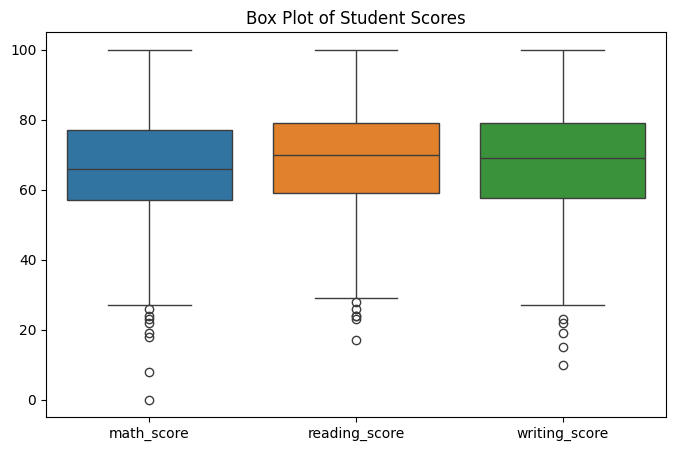

In [ ]:
# Check Outliers
plt.figure(figsize=(8,5))
sns.boxplot(data=df[["math_score","reading_score","writing_score"]])
plt.title("Box Plot of Student Scores")
plt.show()

In [ ]:
#Save the cleaned dataset
df.to_csv("cleaned_students.csv", index=False)

In [ ]:
df.head()

,gender,race_ethnicity,parental_education,lunch,test_preparation,math_score,reading_score,writing_score,total_score,average_score,result,grade
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667,Pass,C
1,female,group C,some college,standard,completed,69,90,88,247,82.333333,Pass,B
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667,Pass,A
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333,Pass,F
4,male,group C,some college,standard,none,76,78,75,229,76.333333,Pass,C


**Part 4: Univariate** **Analysis**

In [ ]:
#import visualization styles
# Set plot style
sns.set_style("whitegrid")

# Set figure size for all plots
plt.rcParams['figure.figsize'] = (8,5)

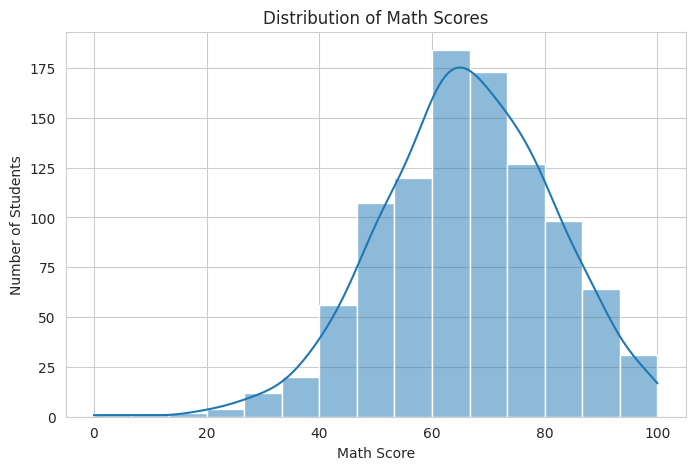

In [ ]:
#Distribution of Math Scores
plt.figure(figsize=(8,5))

sns.histplot(df["math_score"], bins=15, kde=True)

plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Number of Students")

plt.show()
#Shows how math scores are distributed.
#KDE curve represents the density.
#Helps identify skewness and spread.

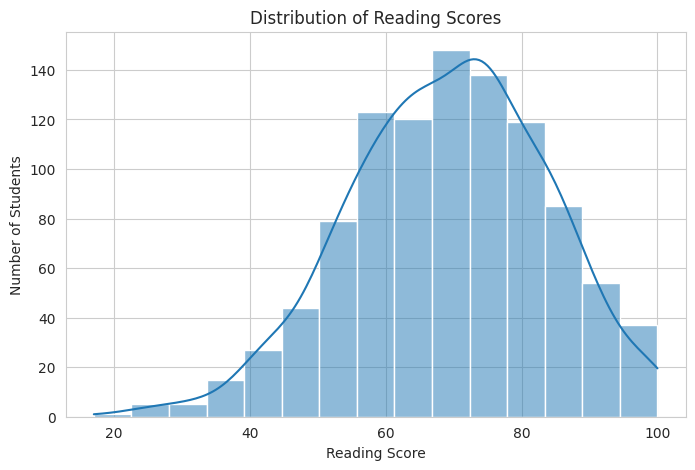

In [ ]:
#Distribution of Reading Scores
plt.figure(figsize=(8,5))

sns.histplot(df["reading_score"], bins=15, kde=True)

plt.title("Distribution of Reading Scores")
plt.xlabel("Reading Score")
plt.ylabel("Number of Students")

plt.show()

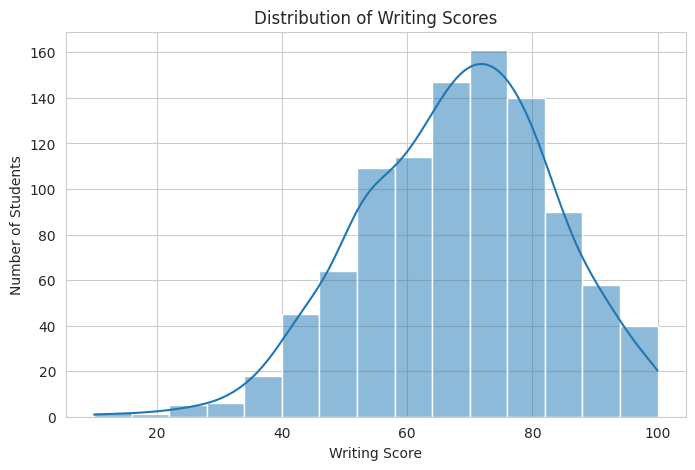

In [ ]:
#Distribution of Writing Scores
plt.figure(figsize=(8,5))

sns.histplot(df["writing_score"], bins=15, kde=True)

plt.title("Distribution of Writing Scores")
plt.xlabel("Writing Score")
plt.ylabel("Number of Students")

plt.show()


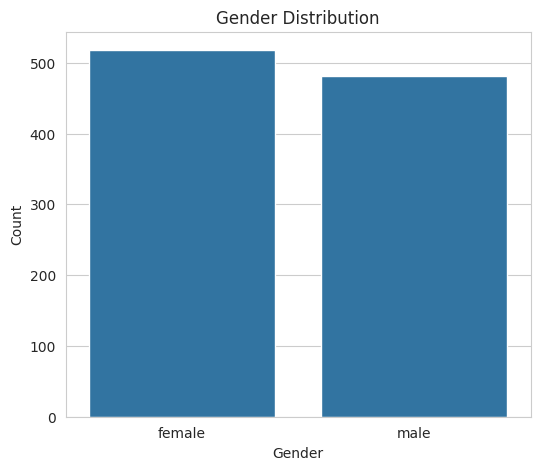

In [ ]:
#Gender Distribution
plt.figure(figsize=(6,5))

sns.countplot(x="gender", data=df)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

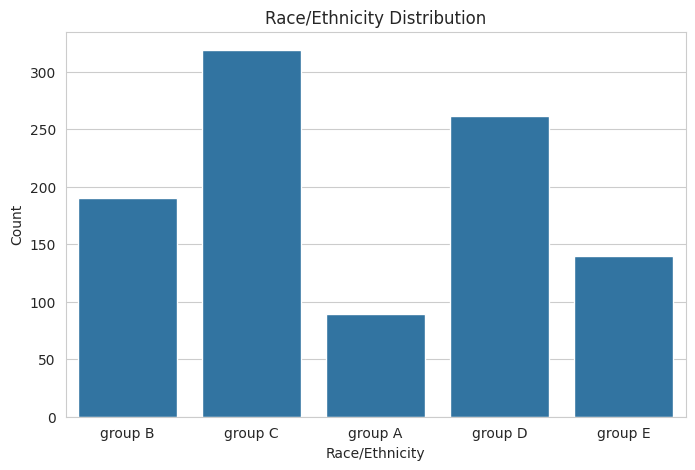

In [ ]:
#Race/Ethnicity Distribution
plt.figure(figsize=(8,5))

sns.countplot(x="race_ethnicity", data=df)

plt.title("Race/Ethnicity Distribution")

plt.xlabel("Race/Ethnicity")

plt.ylabel("Count")

plt.show()

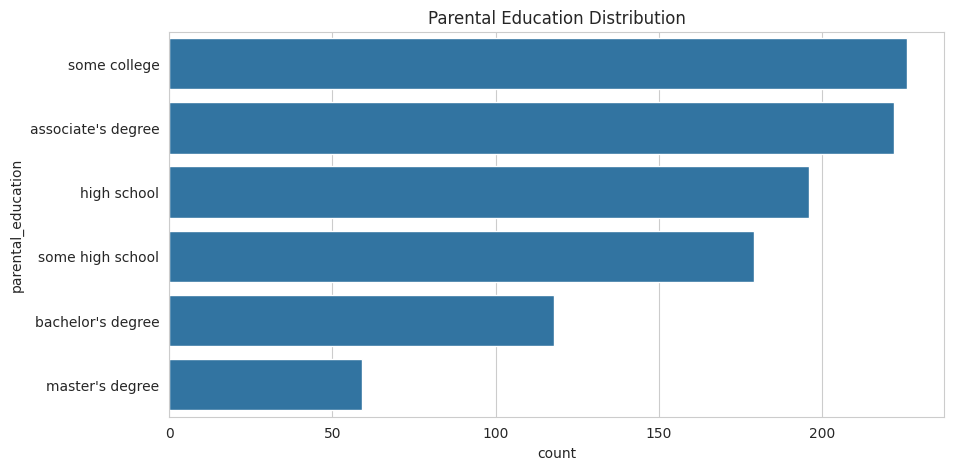

In [ ]:
#Parental Education Distribution
plt.figure(figsize=(10,5))

sns.countplot(
    y="parental_education",
    data=df,
    order=df["parental_education"].value_counts().index
)

plt.title("Parental Education Distribution")

plt.show()

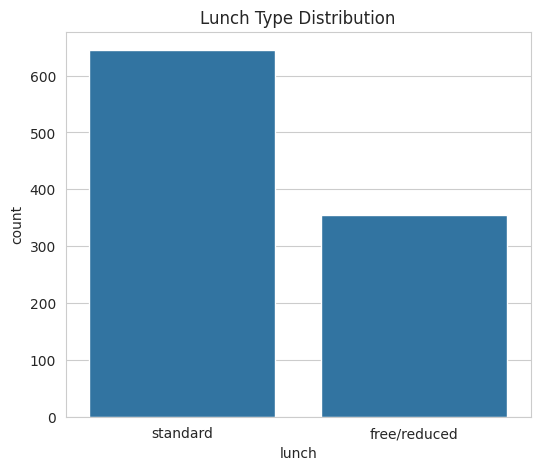

In [ ]:
#Lunch Type Distribution
plt.figure(figsize=(6,5))

sns.countplot(x="lunch", data=df)

plt.title("Lunch Type Distribution")

plt.show()

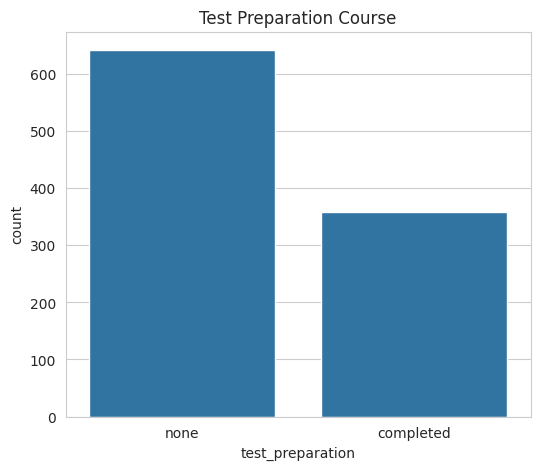

In [ ]:
#Test Preparation Course
plt.figure(figsize=(6,5))

sns.countplot(x="test_preparation", data=df)

plt.title("Test Preparation Course")

plt.show()

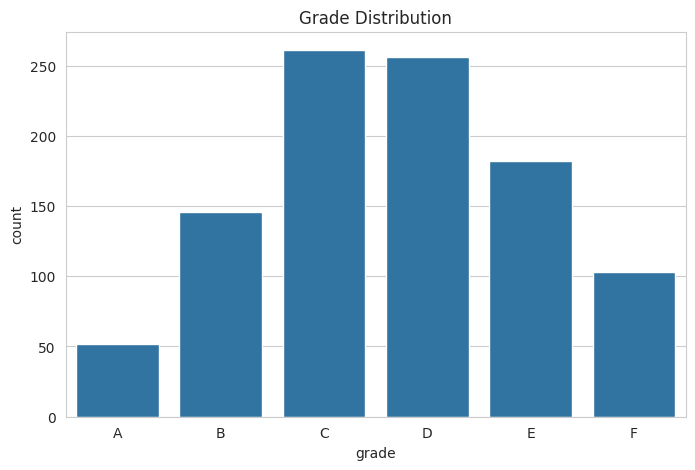

In [ ]:
#Grade Distribution
plt.figure(figsize=(8,5))

sns.countplot(
    x="grade",
    data=df,
    order=["A","B","C","D","E","F"]
)

plt.title("Grade Distribution")

plt.show()

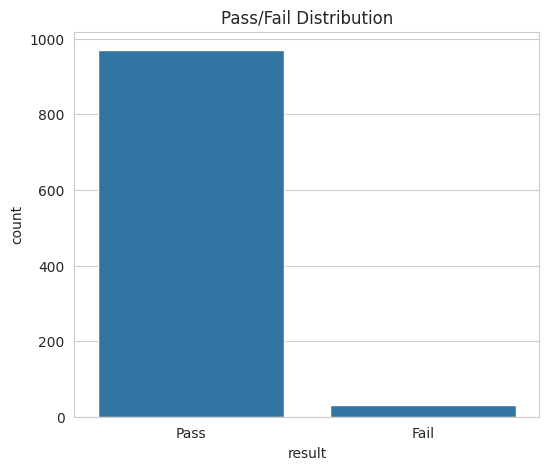

In [ ]:
#Result Distribution
plt.figure(figsize=(6,5))

sns.countplot(x="result", data=df)

plt.title("Pass/Fail Distribution")

plt.show()

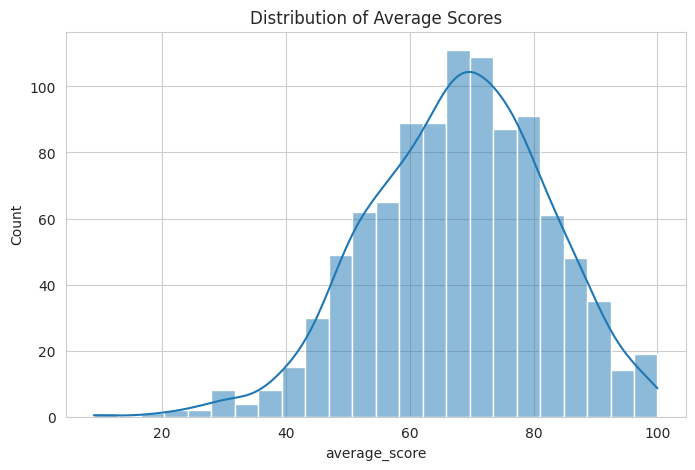

In [ ]:
#Distribution of Average Score
plt.figure(figsize=(8,5))

sns.histplot(df["average_score"], kde=True)

plt.title("Distribution of Average Scores")

plt.show()

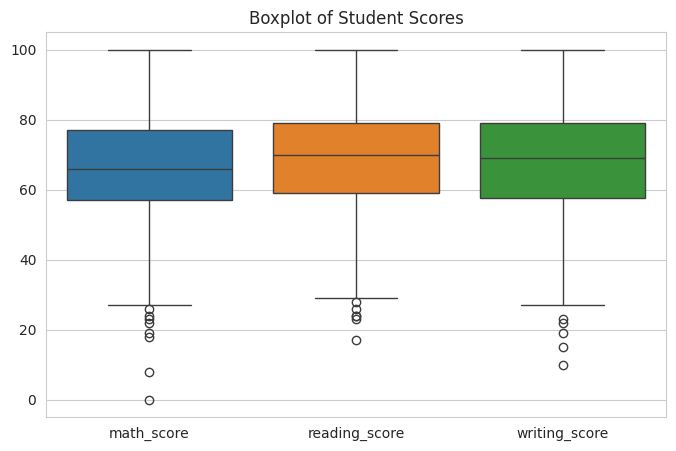

In [ ]:
#Boxplot of Scores
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df[["math_score",
             "reading_score",
             "writing_score"]]
)

plt.title("Boxplot of Student Scores")

plt.show()
#Boxplots help identify:
#Median
#Quartiles
#Outliers
#Score spread

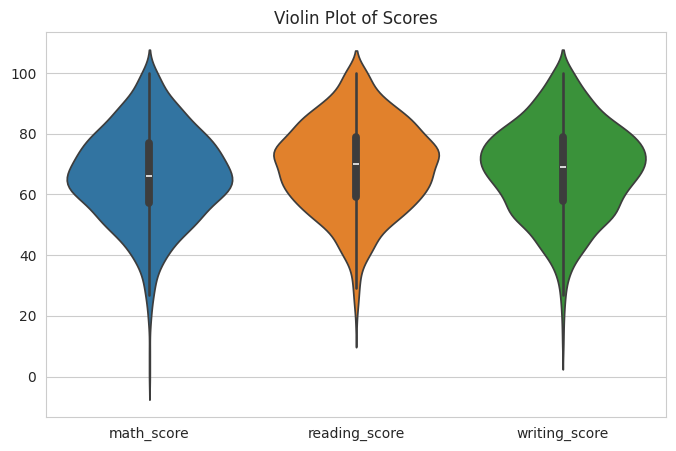

In [ ]:
#Violin Plot
plt.figure(figsize=(8,5))

sns.violinplot(
    data=df[["math_score",
             "reading_score",
             "writing_score"]]
)

plt.title("Violin Plot of Scores")

plt.show()
#Violin plots combine:
#Histogram
#Density curve
#Boxplot

In [ ]:
#Summary Statistics
df[[
    "math_score",
    "reading_score",
    "writing_score",
    "average_score"
]].describe()

,math_score,reading_score,writing_score,average_score
count,1000.00000,1000.000000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000,67.770667
std,15.16308,14.600192,15.195657,14.257326
min,0.00000,17.000000,10.000000,9.000000
25%,57.00000,59.000000,57.750000,58.333333
50%,66.00000,70.000000,69.000000,68.333333
75%,77.00000,79.000000,79.000000,77.666667
max,100.00000,100.000000,100.000000,100.000000


**Part 5: Bivariate Analysis**

In [ ]:
#Average Scores by Gender
gender_scores = df.groupby("gender")[["math_score", "reading_score", "writing_score"]].mean()

gender_scores

,math_score,reading_score,writing_score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


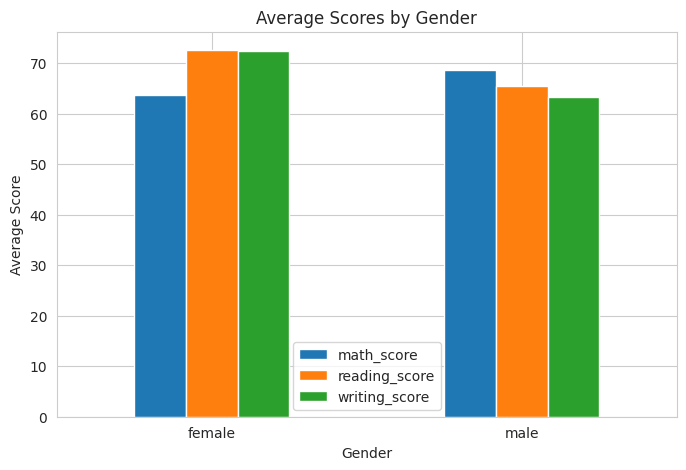

In [ ]:
#visualization
gender_scores.plot(kind="bar", figsize=(8,5))

plt.title("Average Scores by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Score")
plt.xticks(rotation=0)

plt.show()

Observation:
Compare the average scores of male and female students.
Identify which gender performs better in each subject.

In [ ]:
#Average Scores by Test Preparation
prep_scores = df.groupby("test_preparation")[["math_score","reading_score","writing_score"]].mean()

prep_scores

,math_score,reading_score,writing_score
test_preparation,,,
completed,69.695531,73.893855,74.418994
none,64.077882,66.534268,64.504673


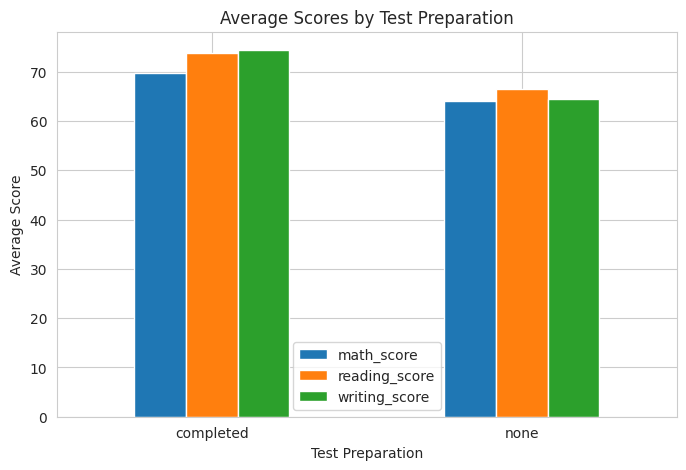

In [ ]:
#visualization
prep_scores.plot(kind="bar", figsize=(8,5))

plt.title("Average Scores by Test Preparation")
plt.xlabel("Test Preparation")
plt.ylabel("Average Score")

plt.xticks(rotation=0)

plt.show()

Observation:

Students who completed the test preparation course generally achieve higher scores.

In [ ]:
#Average Scores by Lunch Type
lunch_scores = df.groupby("lunch")[["math_score","reading_score","writing_score"]].mean()

lunch_scores

,math_score,reading_score,writing_score
lunch,,,
free/reduced,58.921127,64.653521,63.022535
standard,70.034109,71.654264,70.823256


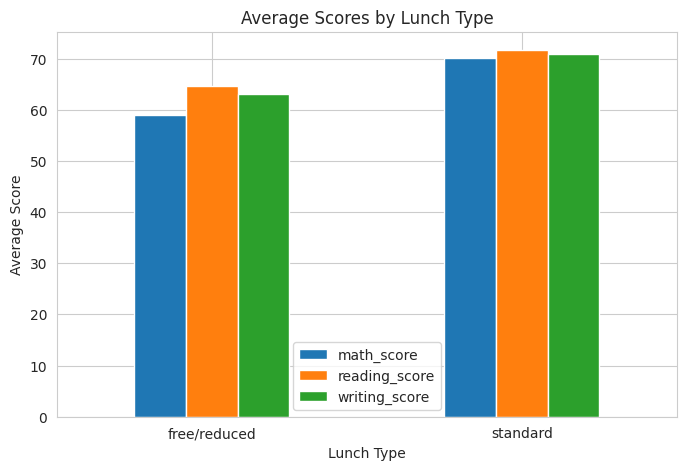

In [ ]:
#Visualization
lunch_scores.plot(kind="bar", figsize=(8,5))

plt.title("Average Scores by Lunch Type")
plt.xlabel("Lunch Type")
plt.ylabel("Average Score")

plt.xticks(rotation=0)

plt.show()

Observation:

Compare the academic performance of students with:

Standard Lunch
Free/Reduced Lunch

In [ ]:
#Average Scores by Parental Education
parent_scores = df.groupby("parental_education")[["math_score","reading_score","writing_score"]].mean()

parent_scores

,math_score,reading_score,writing_score
parental_education,,,
associate's degree,67.882883,70.927928,69.896396
bachelor's degree,69.389831,73.000000,73.381356
high school,62.137755,64.704082,62.448980
master's degree,69.745763,75.372881,75.677966
some college,67.128319,69.460177,68.840708
some high school,63.497207,66.938547,64.888268


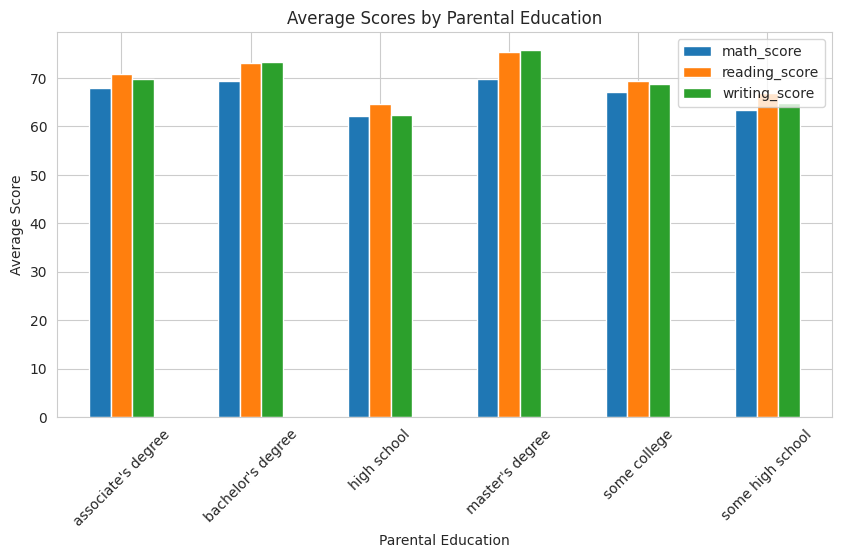

In [ ]:
#visualization
parent_scores.plot(kind="bar", figsize=(10,5))

plt.title("Average Scores by Parental Education")
plt.xlabel("Parental Education")
plt.ylabel("Average Score")

plt.xticks(rotation=45)

plt.show()

Observation:

Analyze whether students whose parents have higher education levels tend to achieve better scores.

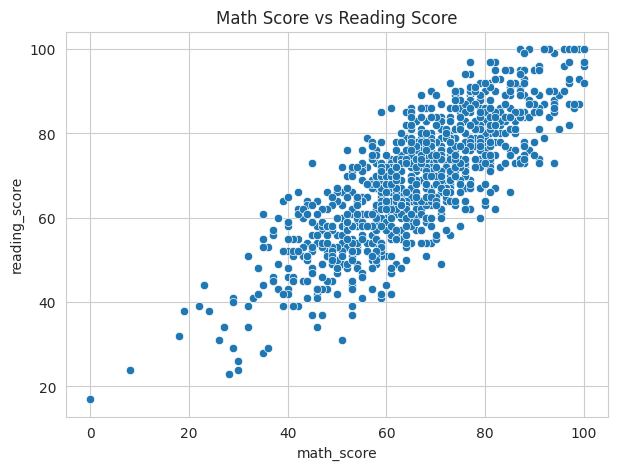

In [ ]:
#Math vs Reading Score
plt.figure(figsize=(7,5))

sns.scatterplot(
    x="math_score",
    y="reading_score",
    data=df
)

plt.title("Math Score vs Reading Score")

plt.show()

Observation:

If the points form an upward trend, there is a positive relationship between Math and Reading scores.

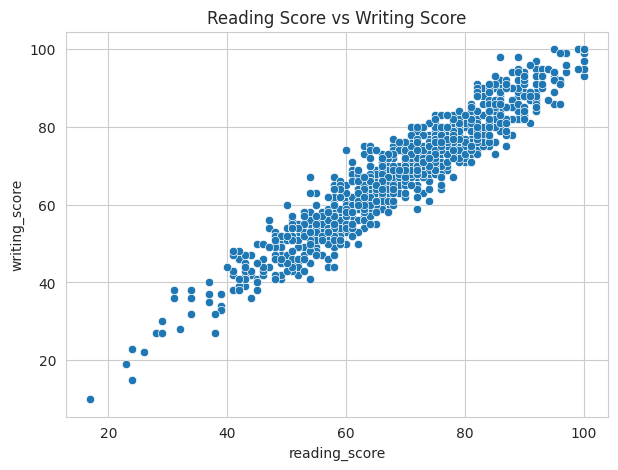

In [ ]:
#Reading vs Writing Score
plt.figure(figsize=(7,5))

sns.scatterplot(
    x="reading_score",
    y="writing_score",
    data=df
)

plt.title("Reading Score vs Writing Score")

plt.show()


Observation:

Reading and Writing scores usually show a strong positive correlation.

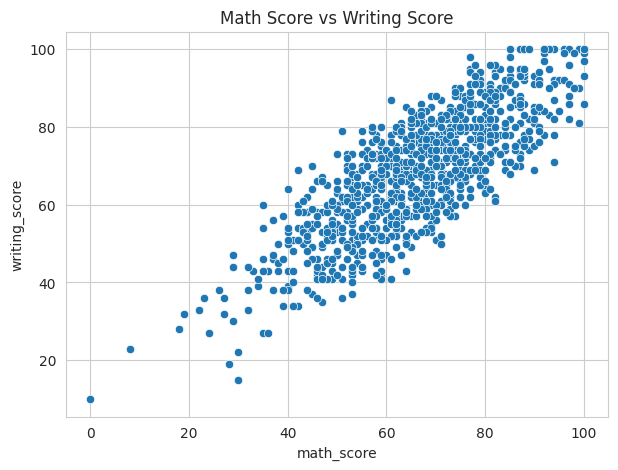

In [ ]:
#Math vs Writing Score
plt.figure(figsize=(7,5))

sns.scatterplot(
    x="math_score",
    y="writing_score",
    data=df
)

plt.title("Math Score vs Writing Score")

plt.show()

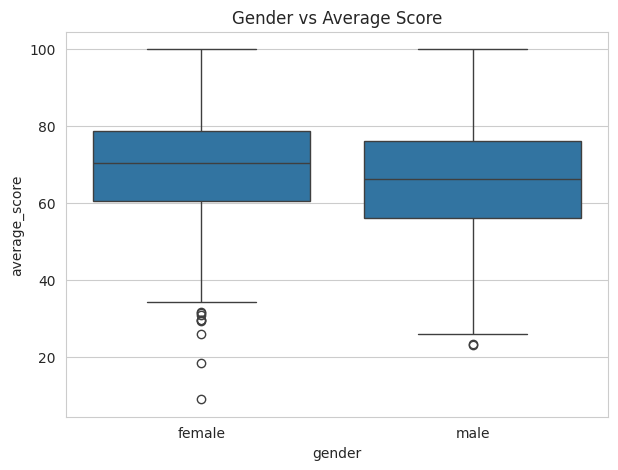

In [ ]:
#Boxplot - Gender vs Average Score
plt.figure(figsize=(7,5))

sns.boxplot(
    x="gender",
    y="average_score",
    data=df
)

plt.title("Gender vs Average Score")

plt.show()

Observation:

This plot compares:

Median
Quartiles
Spread
Outliers

between male and female students.

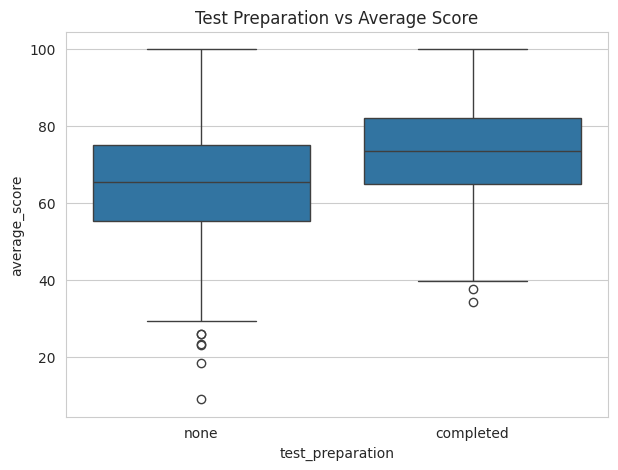

In [ ]:
#Boxplot - Test Preparation vs Average Score
plt.figure(figsize=(7,5))

sns.boxplot(
    x="test_preparation",
    y="average_score",
    data=df
)

plt.title("Test Preparation vs Average Score")

plt.show()

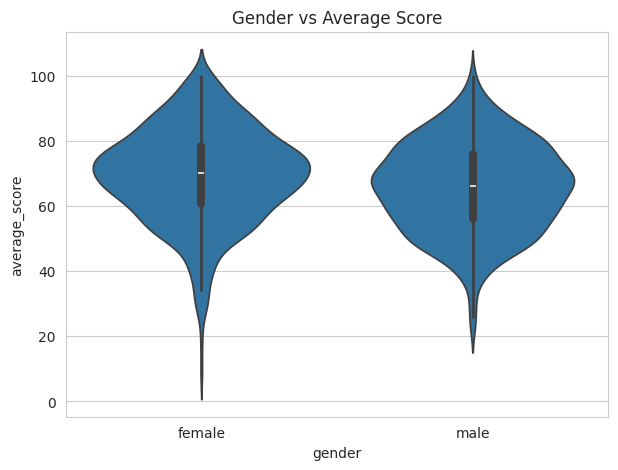

In [ ]:
#Violin Plot - Gender vs Average Score
plt.figure(figsize=(7,5))

sns.violinplot(
    x="gender",
    y="average_score",
    data=df
)

plt.title("Gender vs Average Score")

plt.show()

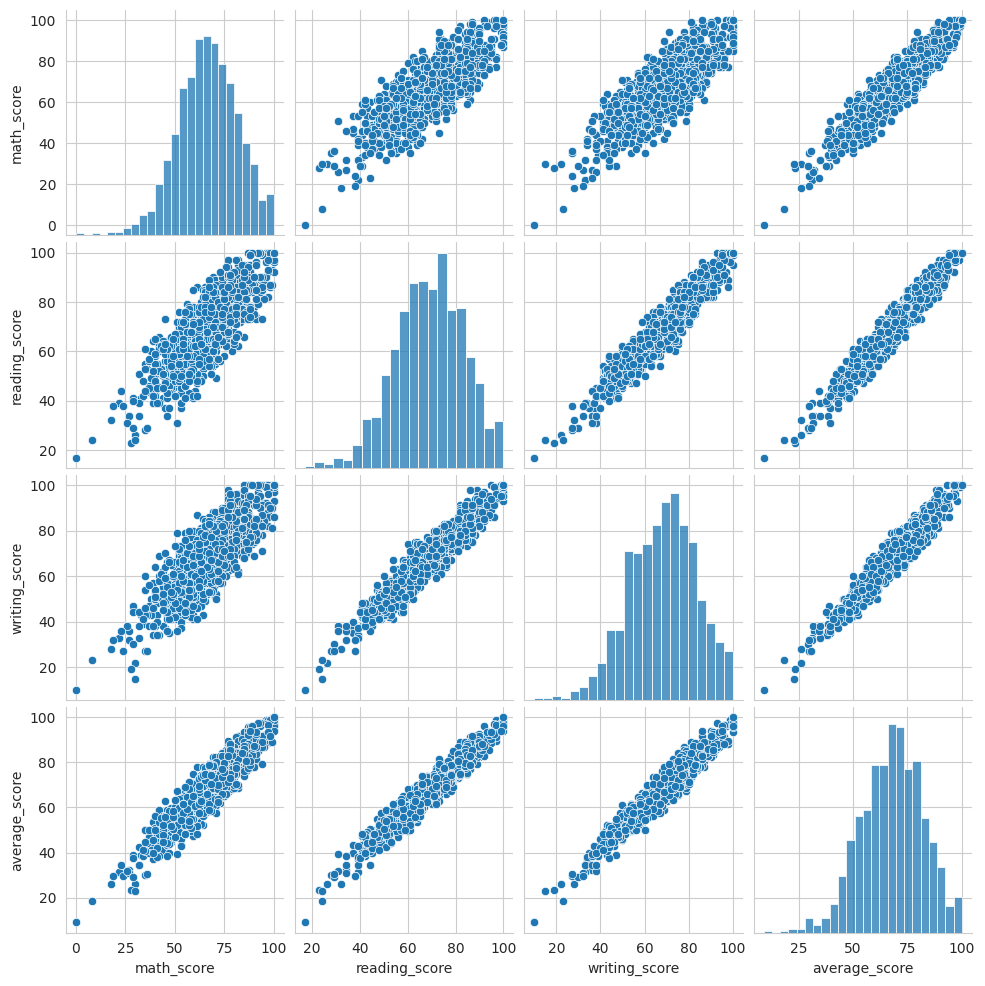

In [ ]:
#Pairplot
sns.pairplot(
    df[[
        "math_score",
        "reading_score",
        "writing_score",
        "average_score"
    ]]
)

plt.show()

Observation:

The pairplot displays:

Histograms on the diagonal
Scatter plots between every pair of numerical variables

It provides a comprehensive overview of relationships among numerical features.

**Part 6: Multivariate Analysis & Correlation Analysis**

In [ ]:
#Correlation Matrix:A correlation matrix shows the strength and direction of relationships between numerical variables.
correlation = df[[
    "math_score",
    "reading_score",
    "writing_score",
    "average_score",
    "total_score"
]].corr()

correlation

,math_score,reading_score,writing_score,average_score,total_score
math_score,1.000000,0.817580,0.802642,0.918746,0.918746
reading_score,0.817580,1.000000,0.954598,0.970331,0.970331
writing_score,0.802642,0.954598,1.000000,0.965667,0.965667
average_score,0.918746,0.970331,0.965667,1.000000,1.000000
total_score,0.918746,0.970331,0.965667,1.000000,1.000000


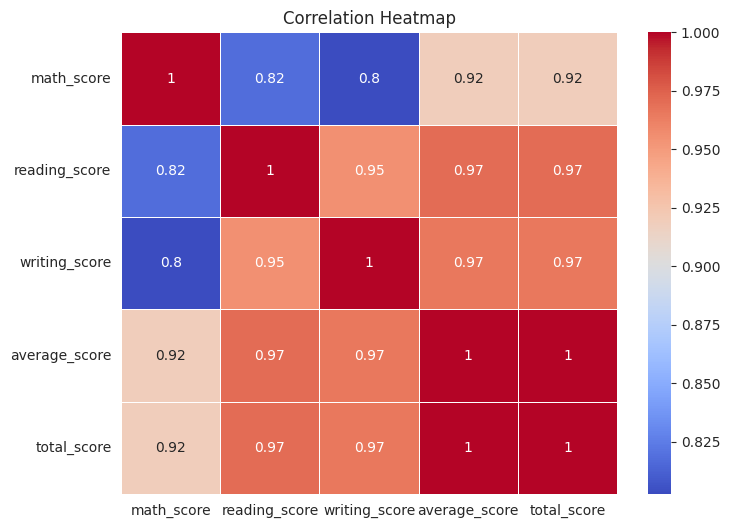

In [ ]:
#Correlation Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

Observation:
Values close to 1 indicate a strong positive relationship.
Values close to 0 indicate little or no relationship.
Reading and Writing scores generally show the highest correlation.

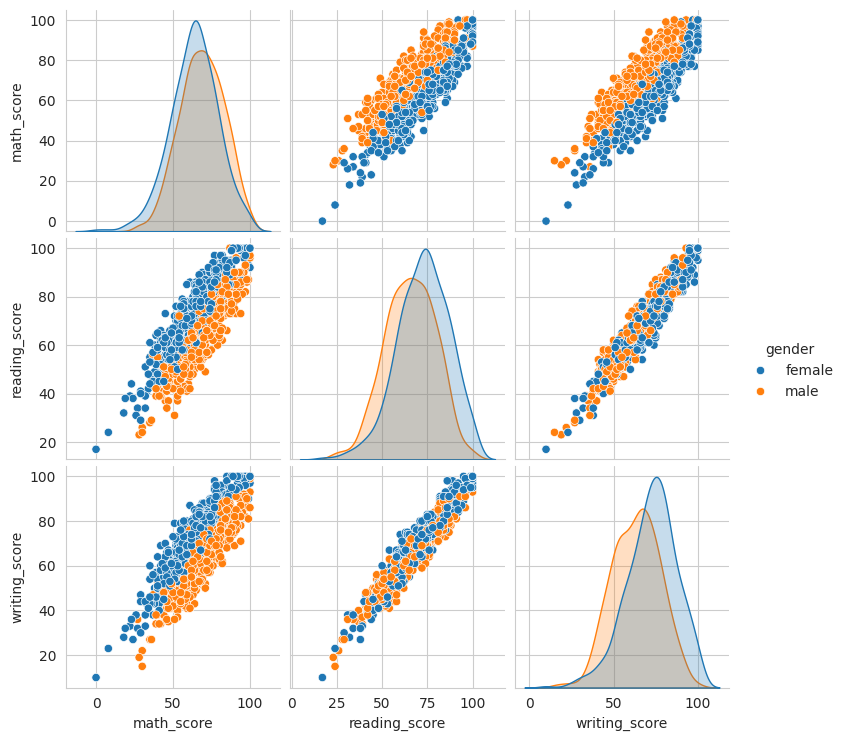

In [ ]:
#Pair Plot with Gender
sns.pairplot(
    df,
    vars=[
        "math_score",
        "reading_score",
        "writing_score"
    ],
    hue="gender"
)

plt.show()

Observation:

Different colors represent male and female students, making it easier to compare score distributions.

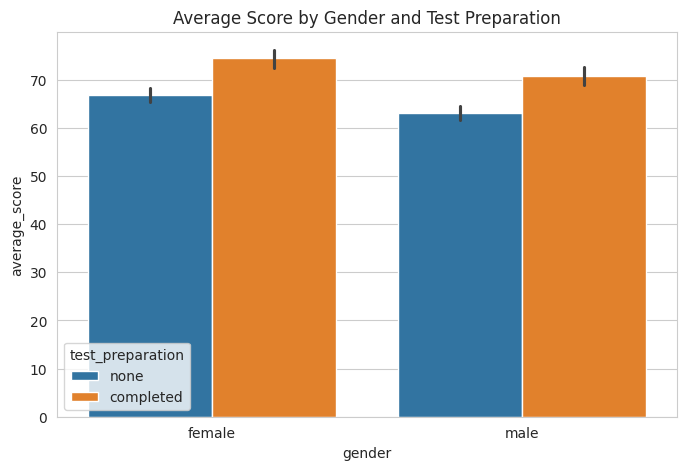

In [ ]:
#Average Score by Gender and Test Preparation
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="gender",
    y="average_score",
    hue="test_preparation"
)

plt.title("Average Score by Gender and Test Preparation")

plt.show()

Observation:

This chart shows how both gender and test preparation together influence average scores.

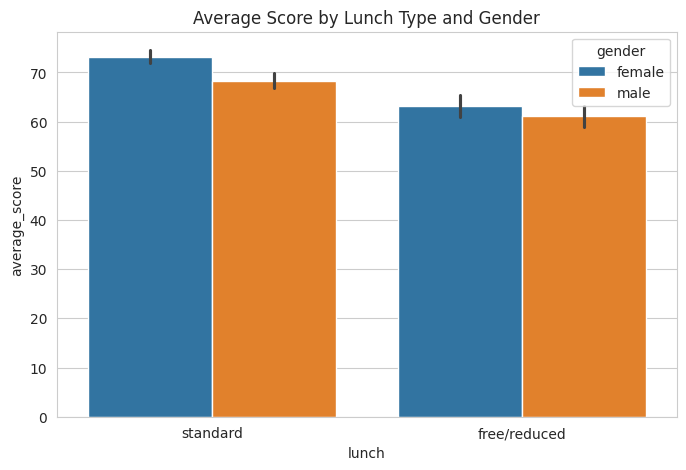

In [ ]:
#Average Score by Lunch and Gender
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="lunch",
    y="average_score",
    hue="gender"
)

plt.title("Average Score by Lunch Type and Gender")

plt.show()

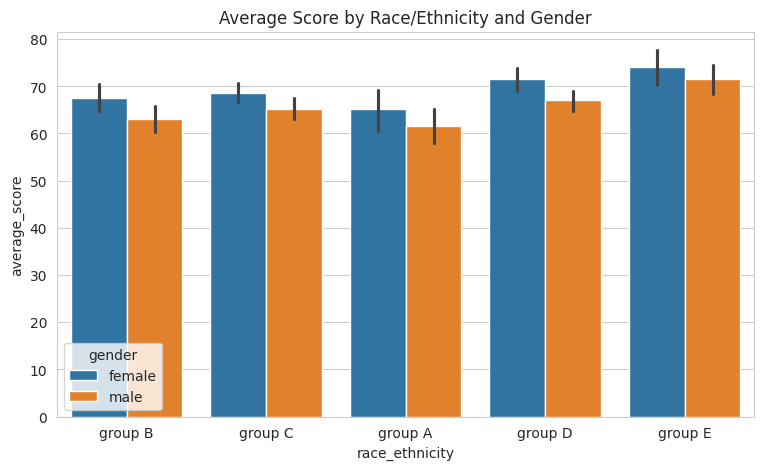

In [ ]:
#Average Score by Race/Ethnicity
plt.figure(figsize=(9,5))

sns.barplot(
    data=df,
    x="race_ethnicity",
    y="average_score",
    hue="gender"
)

plt.title("Average Score by Race/Ethnicity and Gender")

plt.show()

In [ ]:
#Crosstab Analysis:Compare Gender and Result.
pd.crosstab(
    df["gender"],
    df["result"]
)
# for percentages
pd.crosstab(
    df["gender"],
    df["result"],
    normalize="index"
) * 100

result,Fail,Pass
gender,,
female,3.088803,96.911197
male,2.904564,97.095436


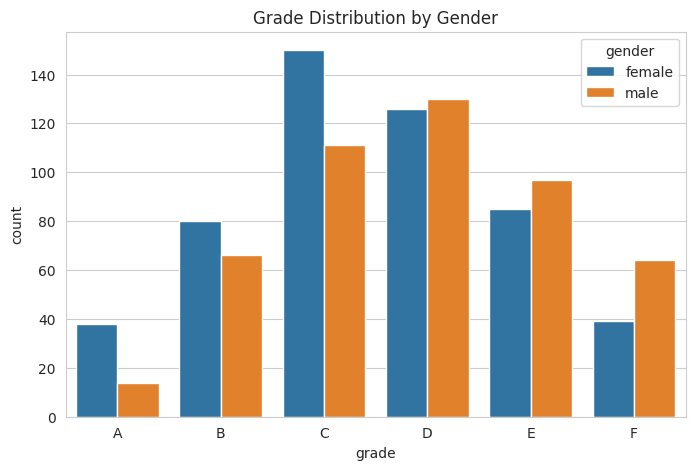

In [ ]:
#Grade Distribution by Gender
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="grade",
    hue="gender",
    order=["A","B","C","D","E","F"]
)

plt.title("Grade Distribution by Gender")

plt.show()

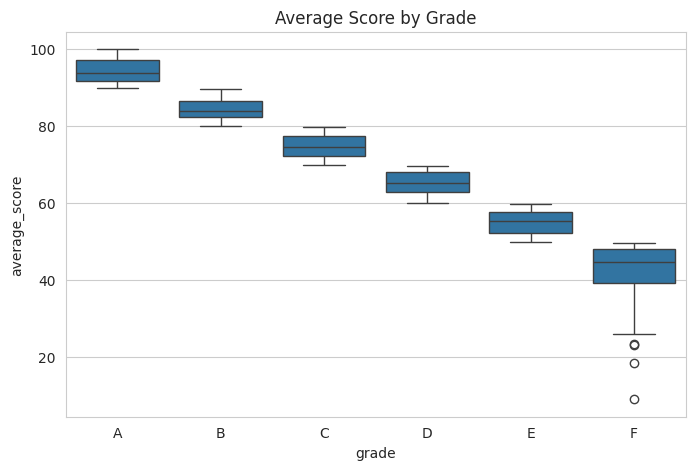

In [ ]:
#Average Score by Grade
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="grade",
    y="average_score",
    order=["A","B","C","D","E","F"]
)

plt.title("Average Score by Grade")

plt.show()

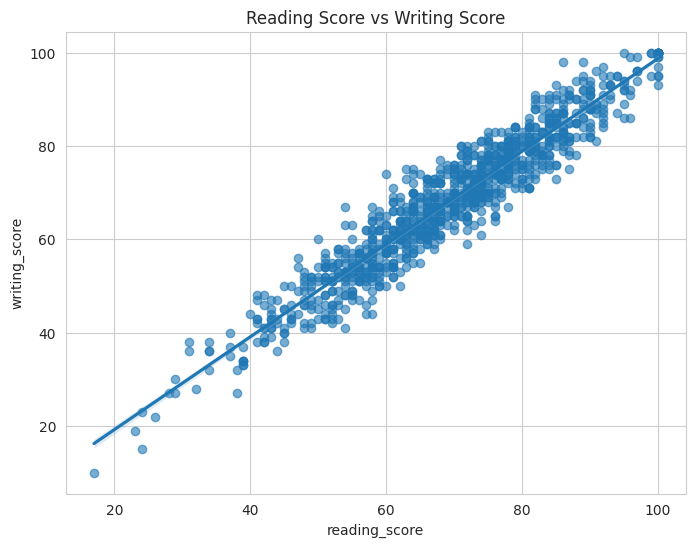

In [ ]:
#Correlation Between Subject Scores
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="reading_score",
    y="writing_score",
    scatter_kws={"alpha":0.6}
)

plt.title("Reading Score vs Writing Score")

plt.show()

In [ ]:
#Summary Table
summary = df.groupby("gender")[[
    "math_score",
    "reading_score",
    "writing_score",
    "average_score"
]].mean()

summary

,math_score,reading_score,writing_score,average_score
gender,,,,
female,63.633205,72.608108,72.467181,69.569498
male,68.728216,65.473029,63.311203,65.837483


In [ ]:
#Export Final Dataset
df.to_csv("Student_Performance_Final.csv", index=False)

#**Part 7: Key Insights**


---


## Key Findings from the Analysis

Based on the exploratory data analysis performed on the Student Performance dataset, the following key insights were observed:

### 1. Student Performance Distribution
Most students scored between **60 and 80 marks** in Mathematics, Reading, and Writing, indicating average overall academic performance.

### 2. Gender-wise Performance
Female students generally performed better in **Reading** and **Writing**, while male students performed slightly better in **Mathematics**.

### 3. Effect of Test Preparation
Students who completed the **test preparation course** consistently achieved higher average scores in all three subjects compared to students who did not complete the course.

### 4. Lunch Type and Academic Performance
Students receiving **standard lunch** generally scored higher than students receiving **free/reduced lunch**, suggesting a possible relationship between nutrition and academic performance.

### 5. Parental Education
Students whose parents had higher education levels generally achieved better academic results, indicating that parental education may positively influence student performance.

### 6. Subject Relationships
A strong positive correlation exists between **Reading** and **Writing** scores. Students who performed well in Reading also tended to perform well in Writing.

### 7. Correlation Analysis
All three subject scores showed positive correlations, indicating that good performance in one subject is often associated with good performance in the others.

### 8. Grade Distribution
Most students achieved grades between **B** and **D**, indicating that the majority demonstrated average academic performance.

### 9. Outlier Detection
A few low-score outliers were identified; however, they represent genuine student performance and were retained in the dataset.

### 10. Overall Observation
Student performance is influenced by multiple factors, including gender, parental education, lunch type, and completion of the test preparation course.

#**Part 8: Conclusion**

This project successfully applied Exploratory Data Analysis (EDA) techniques to examine the academic performance of students.

The dataset was first cleaned and preprocessed by checking for missing values, duplicate records, and appropriate data types. Additional features such as Total Score, Average Score, Grade, and Result were created to enrich the analysis.

Various statistical summaries and visualizations were then used to explore the data. Univariate analysis helped understand the distribution of individual variables, while bivariate and multivariate analyses revealed relationships among different factors affecting student performance.

The analysis indicated that students who completed the test preparation course and those receiving standard lunch generally achieved higher scores. Female students performed better in Reading and Writing, whereas male students slightly outperformed in Mathematics. Strong positive correlations were observed among the three subject scores, particularly between Reading and Writing.

Overall, the project demonstrates how Exploratory Data Analysis can transform raw educational data into meaningful insights that support better academic decision-making.

# **Part 9: Future Scope**

The current project focuses on exploratory analysis of student performance using statistical methods and visualizations. In the future, the project can be extended in several ways:

- Develop machine learning models to predict student performance.
- Identify students at academic risk using classification algorithms.
- Build an interactive dashboard using Power BI, Tableau, or Streamlit.
- Include additional features such as attendance, study hours, sleep duration, and extracurricular activities.
- Perform feature importance analysis to determine the most influential factors affecting student performance.
- Analyze larger educational datasets from multiple schools or universities.
- Deploy the project as a web application for real-time educational analytics.

These enhancements would make the project more suitable for educational institutions and support data-driven academic planning.